In [178]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [179]:
import pandas as pd
import matplotlib.pyplot as plt

In [180]:
df = pd.read_csv('all_stocks_5yr.csv')

In [181]:
print(df['Name'].nunique())

505


In [182]:
df.shape

(619040, 7)

In [183]:
df[df.isnull().any(axis=1)]

,date,open,high,low,close,volume,Name
82949,26/07/2017,NaN,NaN,NaN,69.0842,3,BHF
165734,17/07/2015,NaN,88.76,88.24,88.7200,2056819,DHR
165857,12/01/2016,NaN,NaN,NaN,88.5500,0,DHR
205076,17/07/2015,NaN,48.49,47.85,47.9200,1246786,ES
239832,01/07/2016,NaN,NaN,NaN,49.5400,0,FTV
434379,17/07/2015,NaN,47.31,46.83,46.9900,1229513,O
434502,12/01/2016,NaN,NaN,NaN,52.4300,0,O
478594,09/06/2015,NaN,NaN,NaN,526.0900,12135,REGN
558213,07/04/2016,NaN,NaN,NaN,41.5600,0,UA
581906,12/05/2015,NaN,NaN,NaN,124.0800,569747,VRTX


In [184]:
# 1. מציאת המניות שיש בהן ערכי NaN (חוסרים בנתונים)
stocks_with_nan = df[df.isnull().any(axis=1)]['Name'].unique().tolist()

# הצגת השמות שנמצאו
print(f"נמצאו {len(stocks_with_nan)} מניות עם ערכי NaN:")
print(stocks_with_nan)

נמצאו 9 מניות עם ערכי NaN:
['BHF', 'DHR', 'ES', 'FTV', 'O', 'REGN', 'UA', 'VRTX', 'WRK']


In [185]:
# 2. מציאת המניות ה"חלקיות" (אלו שנסחרו פחות מ-1259 ימים)
counts = df.groupby('Name').size()
incomplete_stocks = counts[counts < 1259].index.tolist()

# הצגת השמות שנמצאו
print(f"נמצאו {len(incomplete_stocks)} מניות שלא נסחרו בכל הימים:")
print(incomplete_stocks)

נמצאו 35 מניות שלא נסחרו בכל הימים:
['ALLE', 'APTV', 'BHF', 'BHGE', 'BMY', 'CFG', 'COTY', 'CSRA', 'DHR', 'DWDP', 'DXC', 'ES', 'EVHC', 'FOX', 'FOXA', 'FTV', 'GOOG', 'HLT', 'HPE', 'HPQ', 'ICE', 'INFO', 'IQV', 'KHC', 'NAVI', 'NWS', 'NWSA', 'O', 'ORCL', 'PYPL', 'QRVO', 'SYF', 'UA', 'WLTW', 'WRK']


In [186]:
# 3. איחוד שתי הרשימות לרשימה אחת סופית (בלי כפילויות)
all_bad_stocks = sorted(list(set(incomplete_stocks + stocks_with_nan)))

# הצגת הרשימה המאוחדת והסופית שיוצאת מהדאטה
print(f"סה''כ מניות להסרה (איחוד של חלקיות + NaN): {len(all_bad_stocks)}")
print("הרשימה המלאה והסופית של המניות שיוסרו:")
print(all_bad_stocks)

# ביצוע הניקוי בפועל
df = df[~df['Name'].isin(all_bad_stocks)].copy()
print(f"\nהניקוי בוצע בהצלחה! נותרו {df['Name'].nunique()} מניות מלאות ותקינות.")

סה''כ מניות להסרה (איחוד של חלקיות + NaN): 37
הרשימה המלאה והסופית של המניות שיוסרו:
['ALLE', 'APTV', 'BHF', 'BHGE', 'BMY', 'CFG', 'COTY', 'CSRA', 'DHR', 'DWDP', 'DXC', 'ES', 'EVHC', 'FOX', 'FOXA', 'FTV', 'GOOG', 'HLT', 'HPE', 'HPQ', 'ICE', 'INFO', 'IQV', 'KHC', 'NAVI', 'NWS', 'NWSA', 'O', 'ORCL', 'PYPL', 'QRVO', 'REGN', 'SYF', 'UA', 'VRTX', 'WLTW', 'WRK']

הניקוי בוצע בהצלחה! נותרו 468 מניות מלאות ותקינות.


In [187]:
print(df['Name'].nunique())

468


In [188]:
df.date = pd.to_datetime(df.date,format="%d/%m/%Y")
df.set_index('date', inplace=True)
df.head()

,open,high,low,close,volume,Name
date,,,,,,
2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [189]:
# שמירת הדאטה הנקי לקובץ CSV חדש
# index=True חשוב כאן כי הגדרנו את התאריך כאינדקס ואנחנו רוצים שהוא יישמר בקובץ
df.to_csv('Cleaned_data.csv', index=True)

print("הקובץ Cleaned_data.csv נשמר בהצלחה!")

הקובץ Cleaned_data.csv נשמר בהצלחה!


Name
A       Axes(0.125,0.2;0.775x0.68)
AAL     Axes(0.125,0.2;0.775x0.68)
AAP     Axes(0.125,0.2;0.775x0.68)
AAPL    Axes(0.125,0.2;0.775x0.68)
ABBV    Axes(0.125,0.2;0.775x0.68)
                   ...            
XYL     Axes(0.125,0.2;0.775x0.68)
YUM     Axes(0.125,0.2;0.775x0.68)
ZBH     Axes(0.125,0.2;0.775x0.68)
ZION    Axes(0.125,0.2;0.775x0.68)
ZTS     Axes(0.125,0.2;0.775x0.68)
Name: close, Length: 468, dtype: object

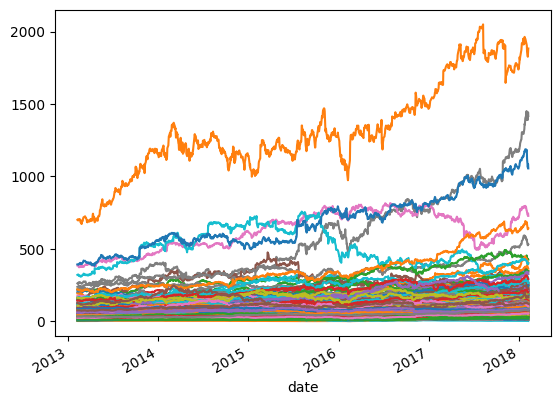

In [190]:
df.groupby('Name')["close"].plot(kind='line')

In [191]:
df['percent_change'] = df.groupby('Name')['close'].transform(lambda x: (x - x.iloc[0]) / x.iloc[0] * 100)

Name
A       Axes(0.125,0.2;0.775x0.68)
AAL     Axes(0.125,0.2;0.775x0.68)
AAP     Axes(0.125,0.2;0.775x0.68)
AAPL    Axes(0.125,0.2;0.775x0.68)
ABBV    Axes(0.125,0.2;0.775x0.68)
                   ...            
XYL     Axes(0.125,0.2;0.775x0.68)
YUM     Axes(0.125,0.2;0.775x0.68)
ZBH     Axes(0.125,0.2;0.775x0.68)
ZION    Axes(0.125,0.2;0.775x0.68)
ZTS     Axes(0.125,0.2;0.775x0.68)
Name: percent_change, Length: 468, dtype: object

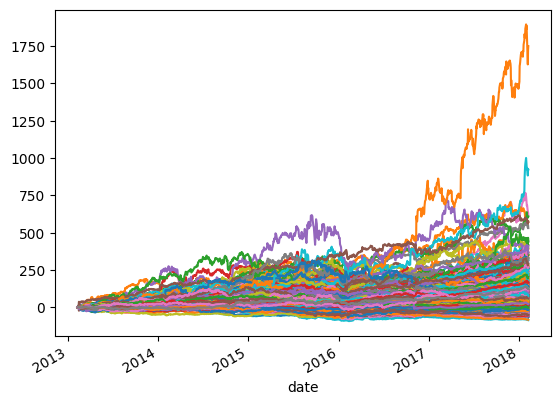

In [192]:
df.groupby('Name')["percent_change"].plot(kind='line')

Name
AAPL    Axes(0.125,0.2;0.775x0.68)
Name: close, dtype: object

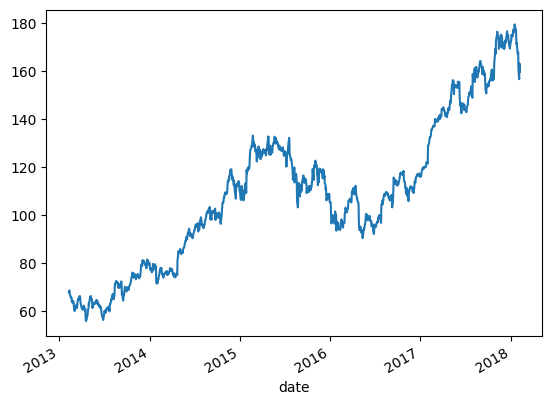

In [193]:
df[df.Name == 'AAPL'].groupby('Name')["close"].plot(kind='line')

Name
AAPL    Axes(0.125,0.2;0.775x0.68)
Name: percent_change, dtype: object

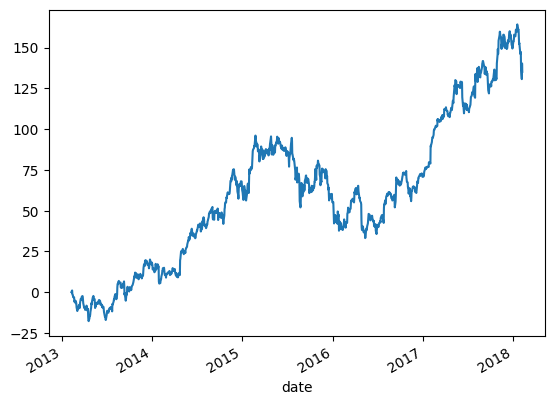

In [194]:
df[df.Name == 'AAPL'].groupby('Name')["percent_change"].plot(kind='line')